# NChain Q-Learning Homework

This notebook implements an NChain game where the probability of action flip is `alpha`. It then runs epsilon-greedy Q-learning for 4000 episodes with `alpha = 0`, stores the average reward and Q-table, plots average reward over episodes, prints the final Q-table, and plots the `Q[4, 1]` element over episodes.

In [1]:
import json
import os
from dataclasses import dataclass
from pathlib import Path

os.environ.setdefault("MPLBACKEND", "Agg")
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mplconfig")

import matplotlib.pyplot as plt
import numpy as np

OUTPUT_DIR = Path("nchain_results")
OUTPUT_DIR.mkdir(exist_ok=True)

## 1. Develop NChain game

The environment has 5 states, numbered `0` through `4`.

- Action `0`: forward, moves to the next state; at state `4`, reward `10`
- Action `1`: backward, returns to state `0`, reward `2`
- With probability `alpha`, the chosen action is flipped before it is applied

In [2]:
@dataclass
class NChain:
    n_states: int = 5
    flip_alpha: float = 0.0
    small_reward: float = 2.0
    large_reward: float = 10.0

    def __post_init__(self):
        if not 0.0 <= self.flip_alpha <= 1.0:
            raise ValueError("flip_alpha must be between 0 and 1.")
        self.state = 0

    def reset(self):
        self.state = 0
        return self.state

    def step(self, action, rng):
        if action not in (0, 1):
            raise ValueError("action must be 0(forward) or 1(backward).")

        if rng.random() < self.flip_alpha:
            action = 1 - action

        if action == 1:
            self.state = 0
            return self.state, self.small_reward

        if self.state == self.n_states - 1:
            return self.state, self.large_reward

        self.state += 1
        return self.state, 0.0

## 2. Execute NChain with alpha = 0 using epsilon-greedy Q-learning

In [3]:
def choose_action(q_table, state, epsilon, rng):
    if rng.random() < epsilon:
        return int(rng.integers(0, q_table.shape[1]))
    return int(np.argmax(q_table[state]))


def run_q_learning(
    flip_alpha=0.0,
    episodes=4000,
    max_steps=100,
    learning_rate=0.1,
    discount=0.95,
    epsilon_start=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.995,
    seed=7,
):
    rng = np.random.default_rng(seed)
    env = NChain(flip_alpha=flip_alpha)
    q_table = np.zeros((env.n_states, 2), dtype=float)

    episode_average_rewards = []
    q_4_1_history = []
    q_table_history = []
    epsilon = epsilon_start

    for episode in range(episodes):
        state = env.reset()
        total_reward = 0.0

        for step in range(max_steps):
            action = choose_action(q_table, state, epsilon, rng)
            next_state, reward = env.step(action, rng)
            total_reward += reward

            td_target = reward + discount * np.max(q_table[next_state])
            q_table[state, action] += learning_rate * (td_target - q_table[state, action])
            state = next_state

        episode_average_rewards.append(total_reward / max_steps)
        q_4_1_history.append(float(q_table[4, 1]))
        q_table_history.append(q_table.copy())
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return {
        "episode_average_rewards": np.array(episode_average_rewards),
        "q_4_1_history": np.array(q_4_1_history),
        "q_table_history": np.array(q_table_history),
        "last_q_table": q_table,
    }


results = run_q_learning(flip_alpha=0.0, episodes=4000)
average_rewards = results["episode_average_rewards"]
q_4_1_history = results["q_4_1_history"]
last_q_table = results["last_q_table"]

print("Final average reward:", average_rewards[-1])
print("Mean average reward over last 100 episodes:", average_rewards[-100:].mean())

Final average reward: 9.6
Mean average reward over last 100 episodes: 9.361600000000001


## Store average reward and Q-table

In [4]:
episodes = np.arange(1, len(average_rewards) + 1)

np.savetxt(
    OUTPUT_DIR / "average_reward.csv",
    np.column_stack([episodes, average_rewards]),
    delimiter=",",
    header="episode,average_reward",
    comments="",
)
np.savetxt(
    OUTPUT_DIR / "q_4_1_history.csv",
    np.column_stack([episodes, q_4_1_history]),
    delimiter=",",
    header="episode,Q[4,1]",
    comments="",
)
np.savetxt(
    OUTPUT_DIR / "last_q_table.csv",
    last_q_table,
    delimiter=",",
    header="action_0_forward,action_1_backward",
    comments="",
)
np.save(OUTPUT_DIR / "q_table_history.npy", results["q_table_history"])

summary = {
    "episodes": int(len(average_rewards)),
    "final_average_reward": float(average_rewards[-1]),
    "mean_average_reward_last_100": float(average_rewards[-100:].mean()),
    "last_q_table": last_q_table.tolist(),
    "last_Q[4,1]": float(last_q_table[4, 1]),
}
(OUTPUT_DIR / "summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")

print("Saved files in", OUTPUT_DIR.resolve())

Saved files in /Users/namsugyeong/Desktop/alpha_lab/nchain_results


## 3. Plot average reward with episodes

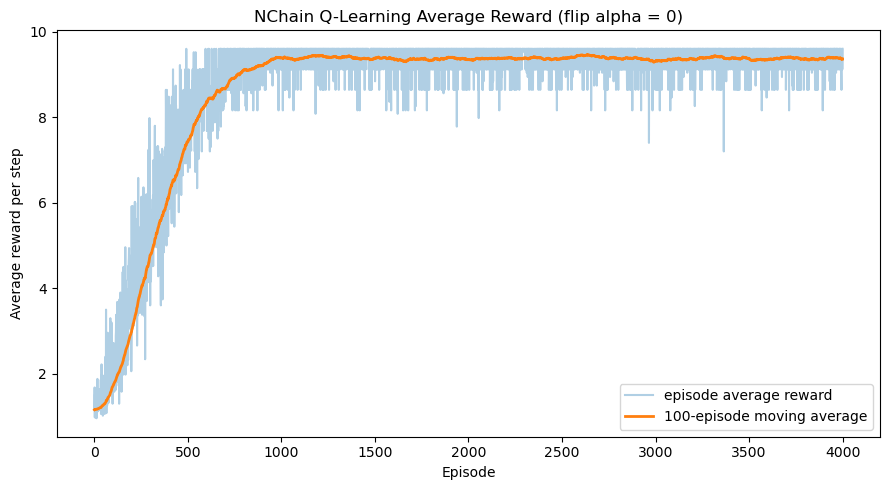

In [5]:
def moving_average(values, window=100):
    values = np.asarray(values, dtype=float)
    kernel = np.ones(window) / window
    padded = np.pad(values, (window - 1, 0), mode="edge")
    return np.convolve(padded, kernel, mode="valid")


plt.figure(figsize=(9, 5))
plt.plot(episodes, average_rewards, alpha=0.35, label="episode average reward")
plt.plot(episodes, moving_average(average_rewards, 100), linewidth=2, label="100-episode moving average")
plt.xlabel("Episode")
plt.ylabel("Average reward per step")
plt.title("NChain Q-Learning Average Reward (flip alpha = 0)")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "average_reward_plot.png", dpi=160)
plt.show()

## 4. Print last Q-table

In [6]:
print("Rows: states 0..4")
print("Columns: action 0(forward), action 1(backward)")
print(np.round(last_q_table, 4))

Rows: states 0..4
Columns: action 0(forward), action 1(backward)
[[162.9012 156.7562]
 [171.475  156.7562]
 [180.5    156.7562]
 [190.     156.7562]
 [200.     156.7562]]


## 5. Plot Q[4, 1] element with episodes

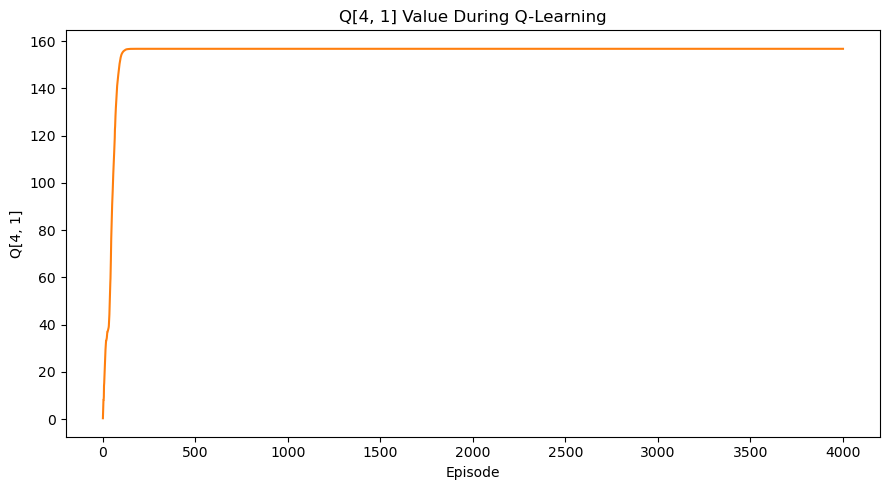

In [7]:
plt.figure(figsize=(9, 5))
plt.plot(episodes, q_4_1_history, color="tab:orange")
plt.xlabel("Episode")
plt.ylabel("Q[4, 1]")
plt.title("Q[4, 1] Value During Q-Learning")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "q_4_1_plot.png", dpi=160)
plt.show()